In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import ScalarFormatter, LogLocator

df_raw = pd.read_csv("reduction_result.csv")
df = df_raw.groupby("N")[["SEQ_MS","PAR_MS","SPEEDUP","EFFICIENCY","COST"]].mean().reset_index()
max_n = int(df["N"].max())
xticks = list(range(0, max_n + 1, max_n // 5))

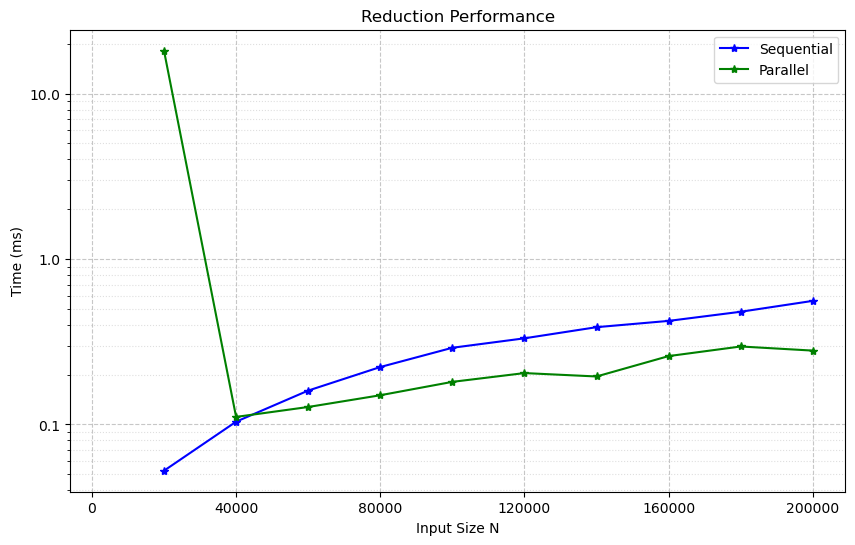

In [22]:
# ================= REDUCTION PERFORMANCE =================
plt.figure(figsize=(10, 6))
plt.ticklabel_format(useOffset=False, style='plain', axis='x')
seq = np.maximum(df["SEQ_MS"], 1e-4)
par = np.maximum(df["PAR_MS"], 1e-4)
plt.plot(df["N"], seq, 'b*-', label='Sequential')
plt.plot(df["N"], par, 'g*-', label='Parallel')
plt.yscale('log')
plt.gca().yaxis.set_major_formatter(ScalarFormatter())
plt.gca().yaxis.set_minor_locator(LogLocator(subs=[2, 3, 4, 5, 6, 7, 8, 9]))
plt.xticks(xticks)
plt.xlim(left=-(xticks[-1] * 0.03))
plt.xlabel("Input Size N")
plt.ylabel("Time (ms)")
plt.title("Reduction Performance")
plt.legend()
plt.grid(True, which='major', linestyle='--', alpha=0.7)
plt.grid(True, which='minor', linestyle=':', alpha=0.4)
plt.show()

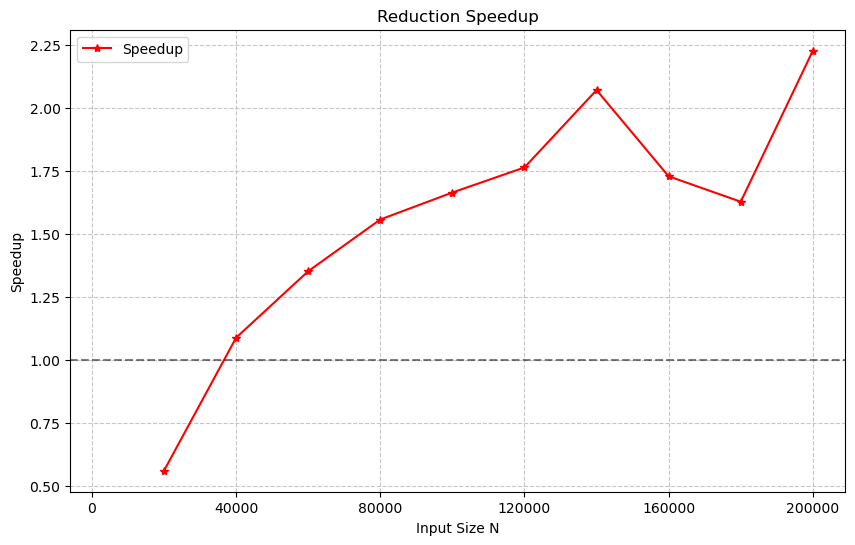

In [23]:
# ================= REDUCTION SPEEDUP =================
plt.figure(figsize=(10, 6))
plt.ticklabel_format(useOffset=False, style='plain', axis='x')
plt.plot(df["N"], df["SPEEDUP"], 'r*-', label='Speedup')
plt.axhline(y=1, color='k', linestyle='--', alpha=0.5)
plt.xticks(xticks)
plt.xlim(left=-(xticks[-1] * 0.03))
plt.xlabel("Input Size N")
plt.ylabel("Speedup")
plt.title("Reduction Speedup")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

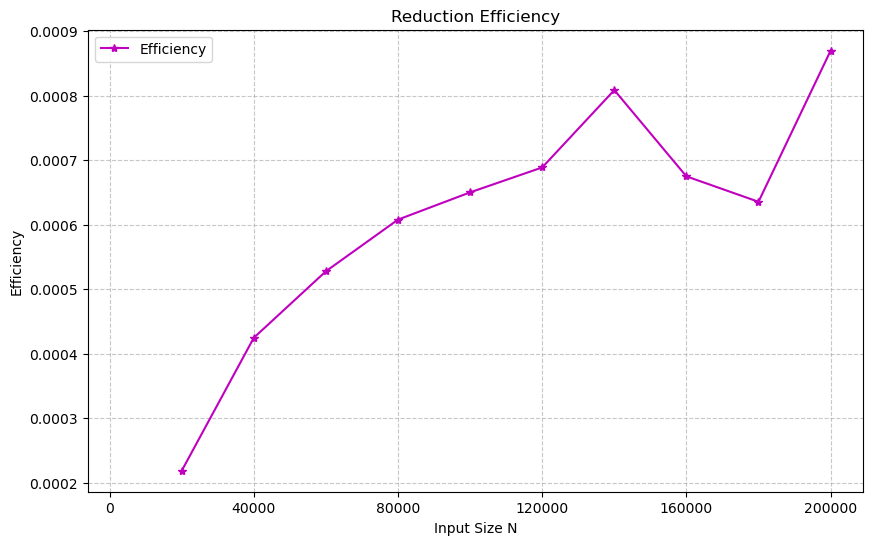

In [24]:
# ================= REDUCTION EFFICIENCY =================
plt.figure(figsize=(10, 6))
plt.ticklabel_format(useOffset=False, style='plain', axis='x')
plt.plot(df["N"], df["EFFICIENCY"], 'm*-', label='Efficiency')
plt.xticks(xticks)
plt.xlim(left=-(xticks[-1] * 0.03))
plt.xlabel("Input Size N")
plt.ylabel("Efficiency")
plt.title("Reduction Efficiency")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

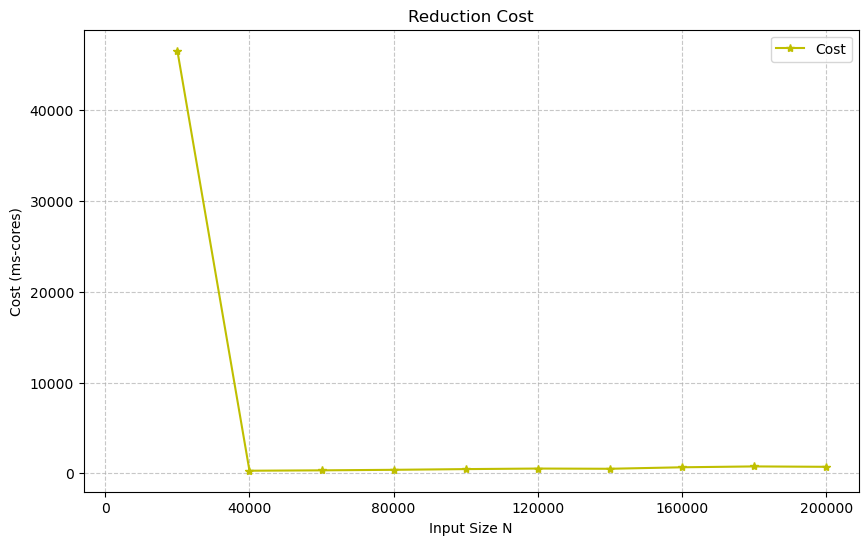

In [25]:
# ================= REDUCTION COST =================
plt.figure(figsize=(10, 6))
plt.ticklabel_format(useOffset=False, style='plain', axis='x')
plt.plot(df["N"], df["COST"], 'y*-', label='Cost')
plt.xticks(xticks)
plt.xlim(left=-(xticks[-1] * 0.03))
plt.xlabel("Input Size N")
plt.ylabel("Cost (ms-cores)")
plt.title("Reduction Cost")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()